In [ ]:
# Importamos las bibliotecas necesarias
# reticulate::py_install("scikit-learn-extra", pip = TRUE)
# pip install scikit-learn-extra
import os
import numpy as np
import pandas as pd
import seaborn as sb
from   math import pi
import plotly.express as px
import No_Supervisados as ns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler
pd.options.display.max_rows = 10
import warnings

In [2]:
import No_Supervisados

In [3]:
# Opción a
path = "/home/dnunezf/Documents/AI_LABS/Lab_05-03-2026/BankChurners.csv"
df = pd.read_csv(path,delimiter=',',decimal=".", index_col=0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 714073983 to 714127383
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            810 non-null    object 
 1   Customer_Age              810 non-null    int64  
 2   Gender                    810 non-null    object 
 3   Dependent_count           810 non-null    int64  
 4   Education_Level           810 non-null    object 
 5   Marital_Status            810 non-null    object 
 6   Income_Category           810 non-null    object 
 7   Months_on_book            810 non-null    int64  
 8   Total_Relationship_Count  810 non-null    int64  
 9   Months_Inactive_12_mon    810 non-null    int64  
 10  Contacts_Count_12_mon     810 non-null    int64  
 11  Credit_Limit              810 non-null    float64
 12  Total_Revolving_Bal       810 non-null    int64  
 13  Total_Trans_Amt           810 non-null    int64  
 14  T

In [5]:
df.shape

(810, 15)

In [6]:
df.dtypes

Attrition_Flag            object
Customer_Age               int64
Gender                    object
Dependent_count            int64
Education_Level           object
                          ...   
Contacts_Count_12_mon      int64
Credit_Limit             float64
Total_Revolving_Bal        int64
Total_Trans_Amt            int64
Total_Trans_Ct             int64
Length: 15, dtype: object

In [7]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct
ID,,,,,,,,,,,,,,,
714073983,Existing Customer,47,M,2,Unknown,Single,$40K - $60K,36,6,3,3,7327.0,0,1788,46
718076733,Existing Customer,43,M,1,Graduate,Single,$60K - $80K,31,4,3,3,25824.0,1170,3101,73
710511858,Existing Customer,58,F,0,Unknown,Married,Less than $40K,36,3,3,3,3832.0,1439,4741,88
766273533,Existing Customer,53,M,2,Uneducated,Unknown,$80K - $120K,46,3,6,3,17190.0,1736,15055,117
779249583,Existing Customer,56,F,1,Graduate,Married,Less than $40K,38,4,3,3,2578.0,2462,1378,29


In [8]:
df_numerico = df.select_dtypes(include = ["number"])

In [9]:
df_numerico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 714073983 to 714127383
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              810 non-null    int64  
 1   Dependent_count           810 non-null    int64  
 2   Months_on_book            810 non-null    int64  
 3   Total_Relationship_Count  810 non-null    int64  
 4   Months_Inactive_12_mon    810 non-null    int64  
 5   Contacts_Count_12_mon     810 non-null    int64  
 6   Credit_Limit              810 non-null    float64
 7   Total_Revolving_Bal       810 non-null    int64  
 8   Total_Trans_Amt           810 non-null    int64  
 9   Total_Trans_Ct            810 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 69.6 KB


In [10]:
#Opción b
import warnings
warnings.filterwarnings('ignore')
# Ejecuta k-medias con 3 clusters
kmedias = KMeans(n_clusters=3, max_iter=500, n_init=150)  # Declara la instancia de clase
kmedias.fit(df_numerico)
print("Grupos\n",kmedias.predict(df_numerico))
centros = np.array(kmedias.cluster_centers_)
print("Centros\n",centros)

Grupos
 [0 1 0 2 0 0 0 0 0 0 0 0 0 0 2 1 0 2 0 0 2 0 2 2 0 0 0 0 0 2 2 0 0 0 0 0 0
 0 0 0 2 1 0 1 0 0 1 0 2 0 0 0 0 2 0 0 2 0 2 0 0 0 0 2 0 0 1 0 0 0 0 0 1 2
 2 0 2 0 0 0 1 0 2 0 0 0 0 0 0 2 1 2 2 2 0 2 0 2 0 0 1 1 0 0 1 1 2 0 0 0 0
 0 0 0 0 0 2 2 2 1 0 0 0 2 0 1 2 0 0 0 0 2 0 1 0 0 0 0 0 1 2 0 1 0 0 1 0 1
 0 0 0 1 0 2 1 0 0 0 0 0 0 2 1 0 0 0 0 0 2 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 2 0 0 0 2 1 0 0 0 2 0 0 1 0 0 2 0 0 2 0 0 0 0 2 2 0 0 1 0 0 0
 0 0 0 1 0 0 0 2 2 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2
 0 0 2 0 0 0 1 0 2 0 2 0 0 0 0 0 1 0 1 0 0 0 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2
 0 2 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 1 0 1 2 1 0 0 0 0 0 0 0 1 2 2 2 0 2 2 0
 0 0 2 0 0 2 0 0 0 0 0 0 0 2 2 0 2 0 1 0 0 2 2 0 2 2 1 0 0 0 0 2 0 0 2 0 2
 2 1 0 2 0 0 2 2 0 0 0 0 2 0 2 0 0 0 2 1 2 2 0 0 0 0 0 0 0 0 2 0 0 2 0 2 0
 0 0 0 0 0 1 0 0 1 0 1 0 0 2 2 0 2 1 2 0 0 0 0 0 2 2 2 1 0 0 0 2 0 0 0 0 0
 2 0 0 2 0 0 0 0 0 0 1 0 0 0 0 2 0 2 1 1 0 0 0 0 2 2 1 0 0 0 0 0 2 0 0 0 0
 2 0 1 2 0 0 0 2 

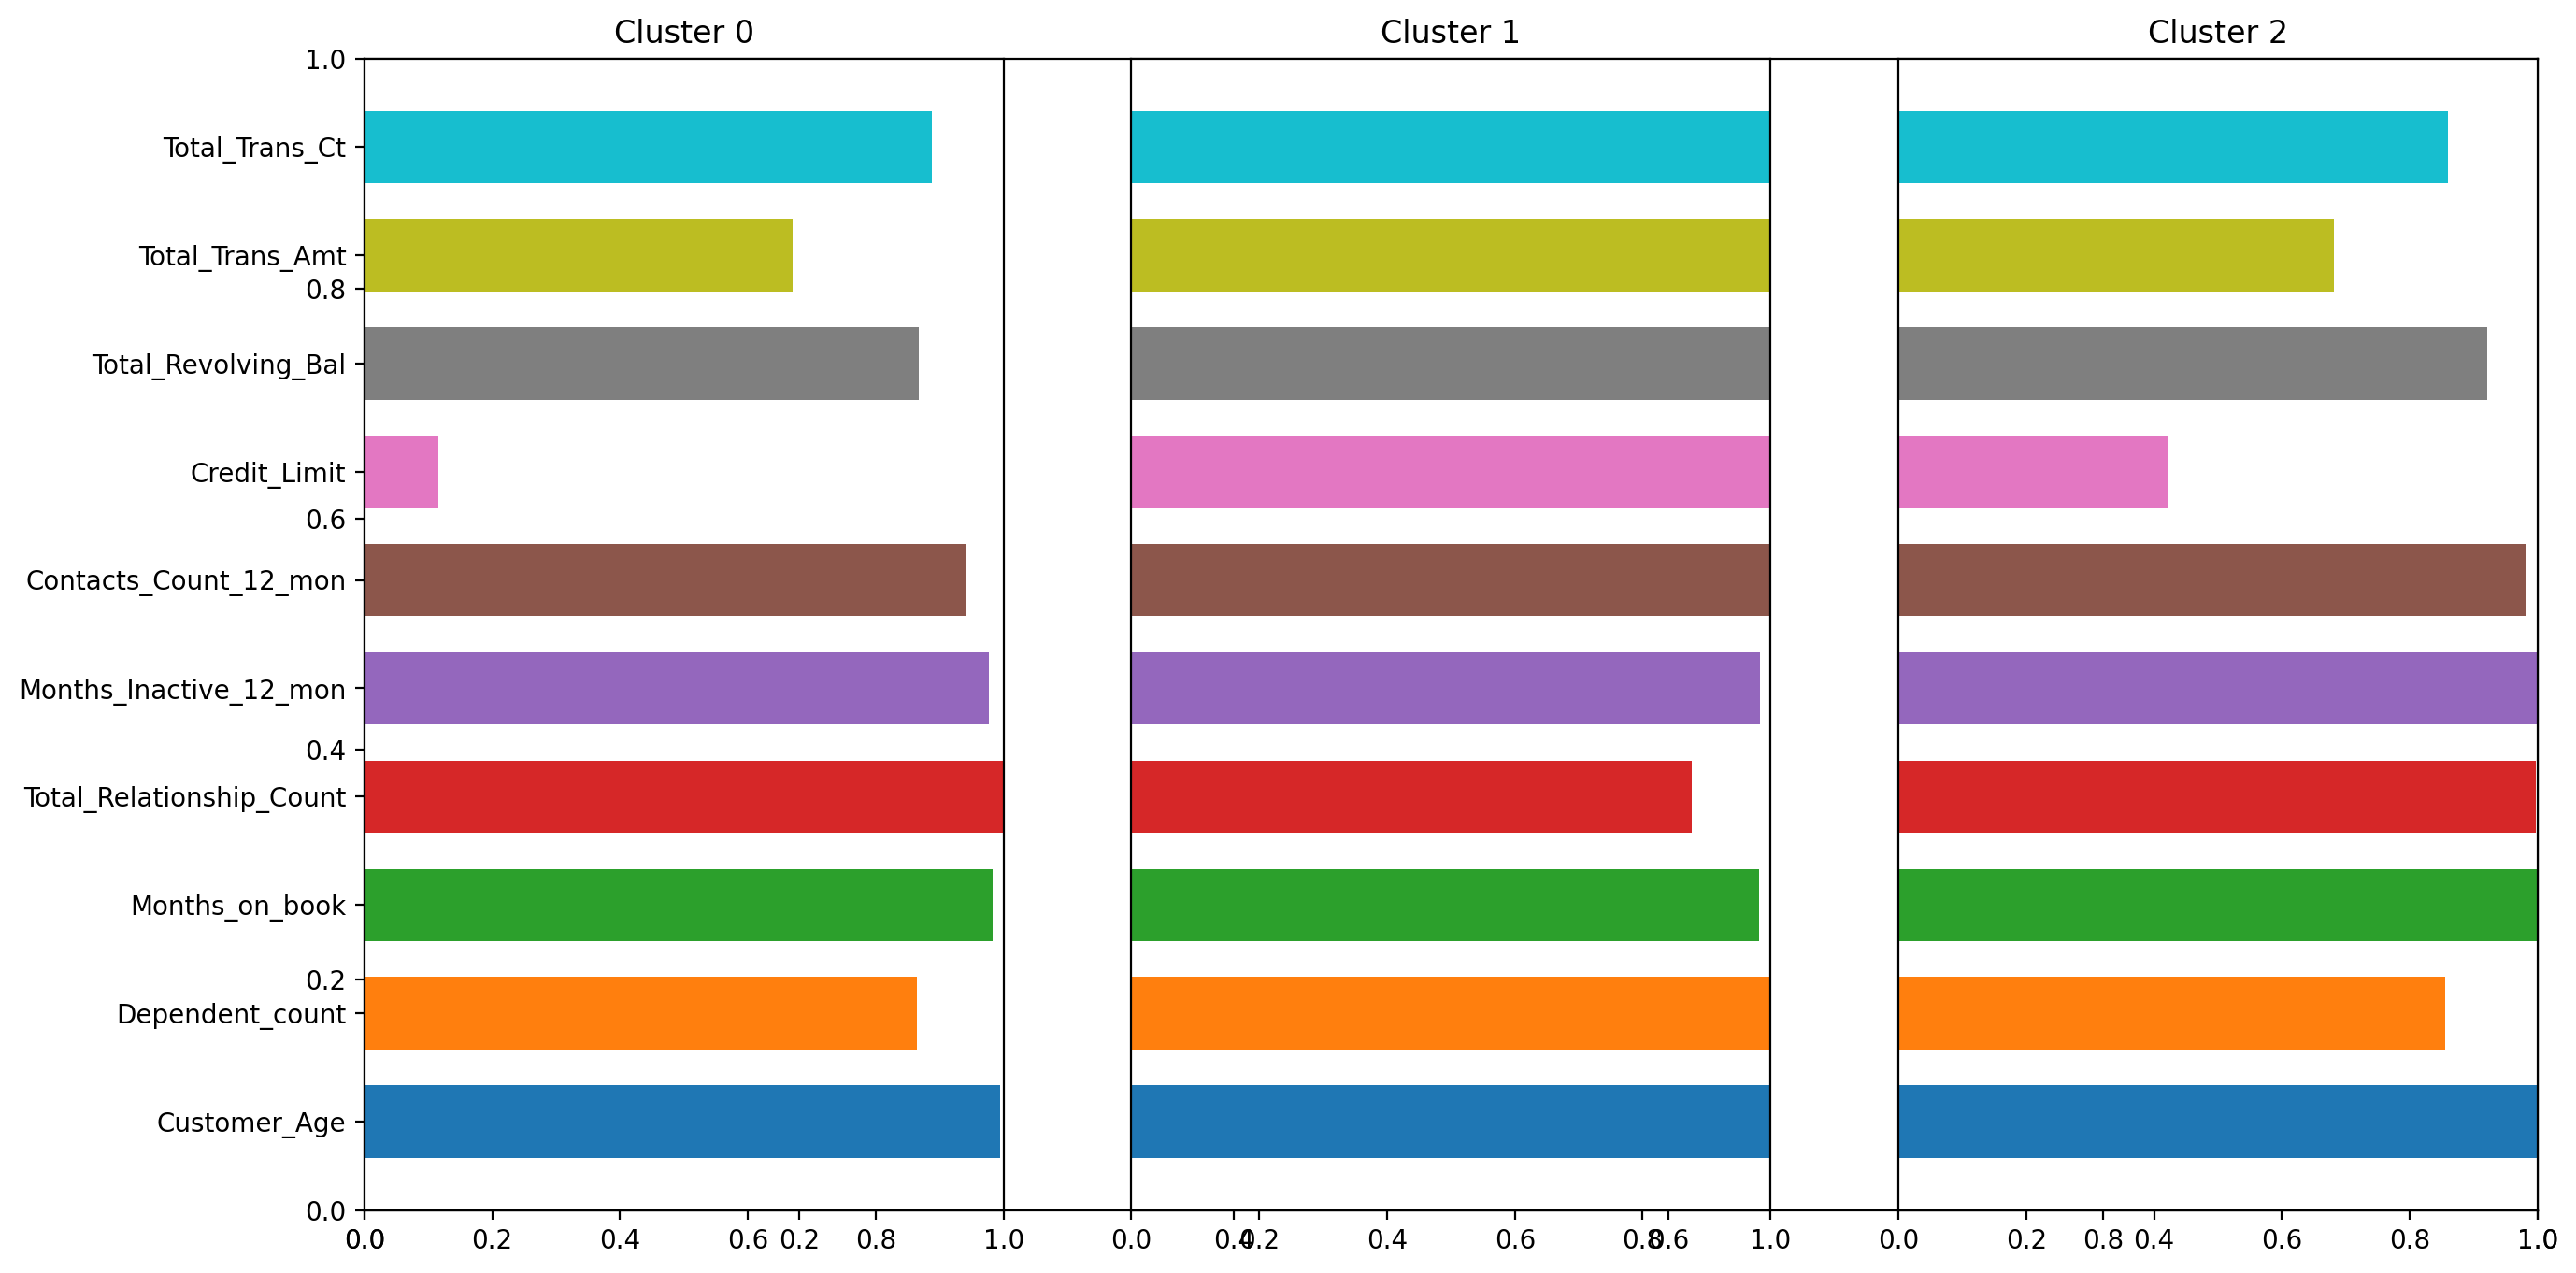

In [12]:
ns.bar_plot(centros, df_numerico.columns,scale=True)
plt.show()

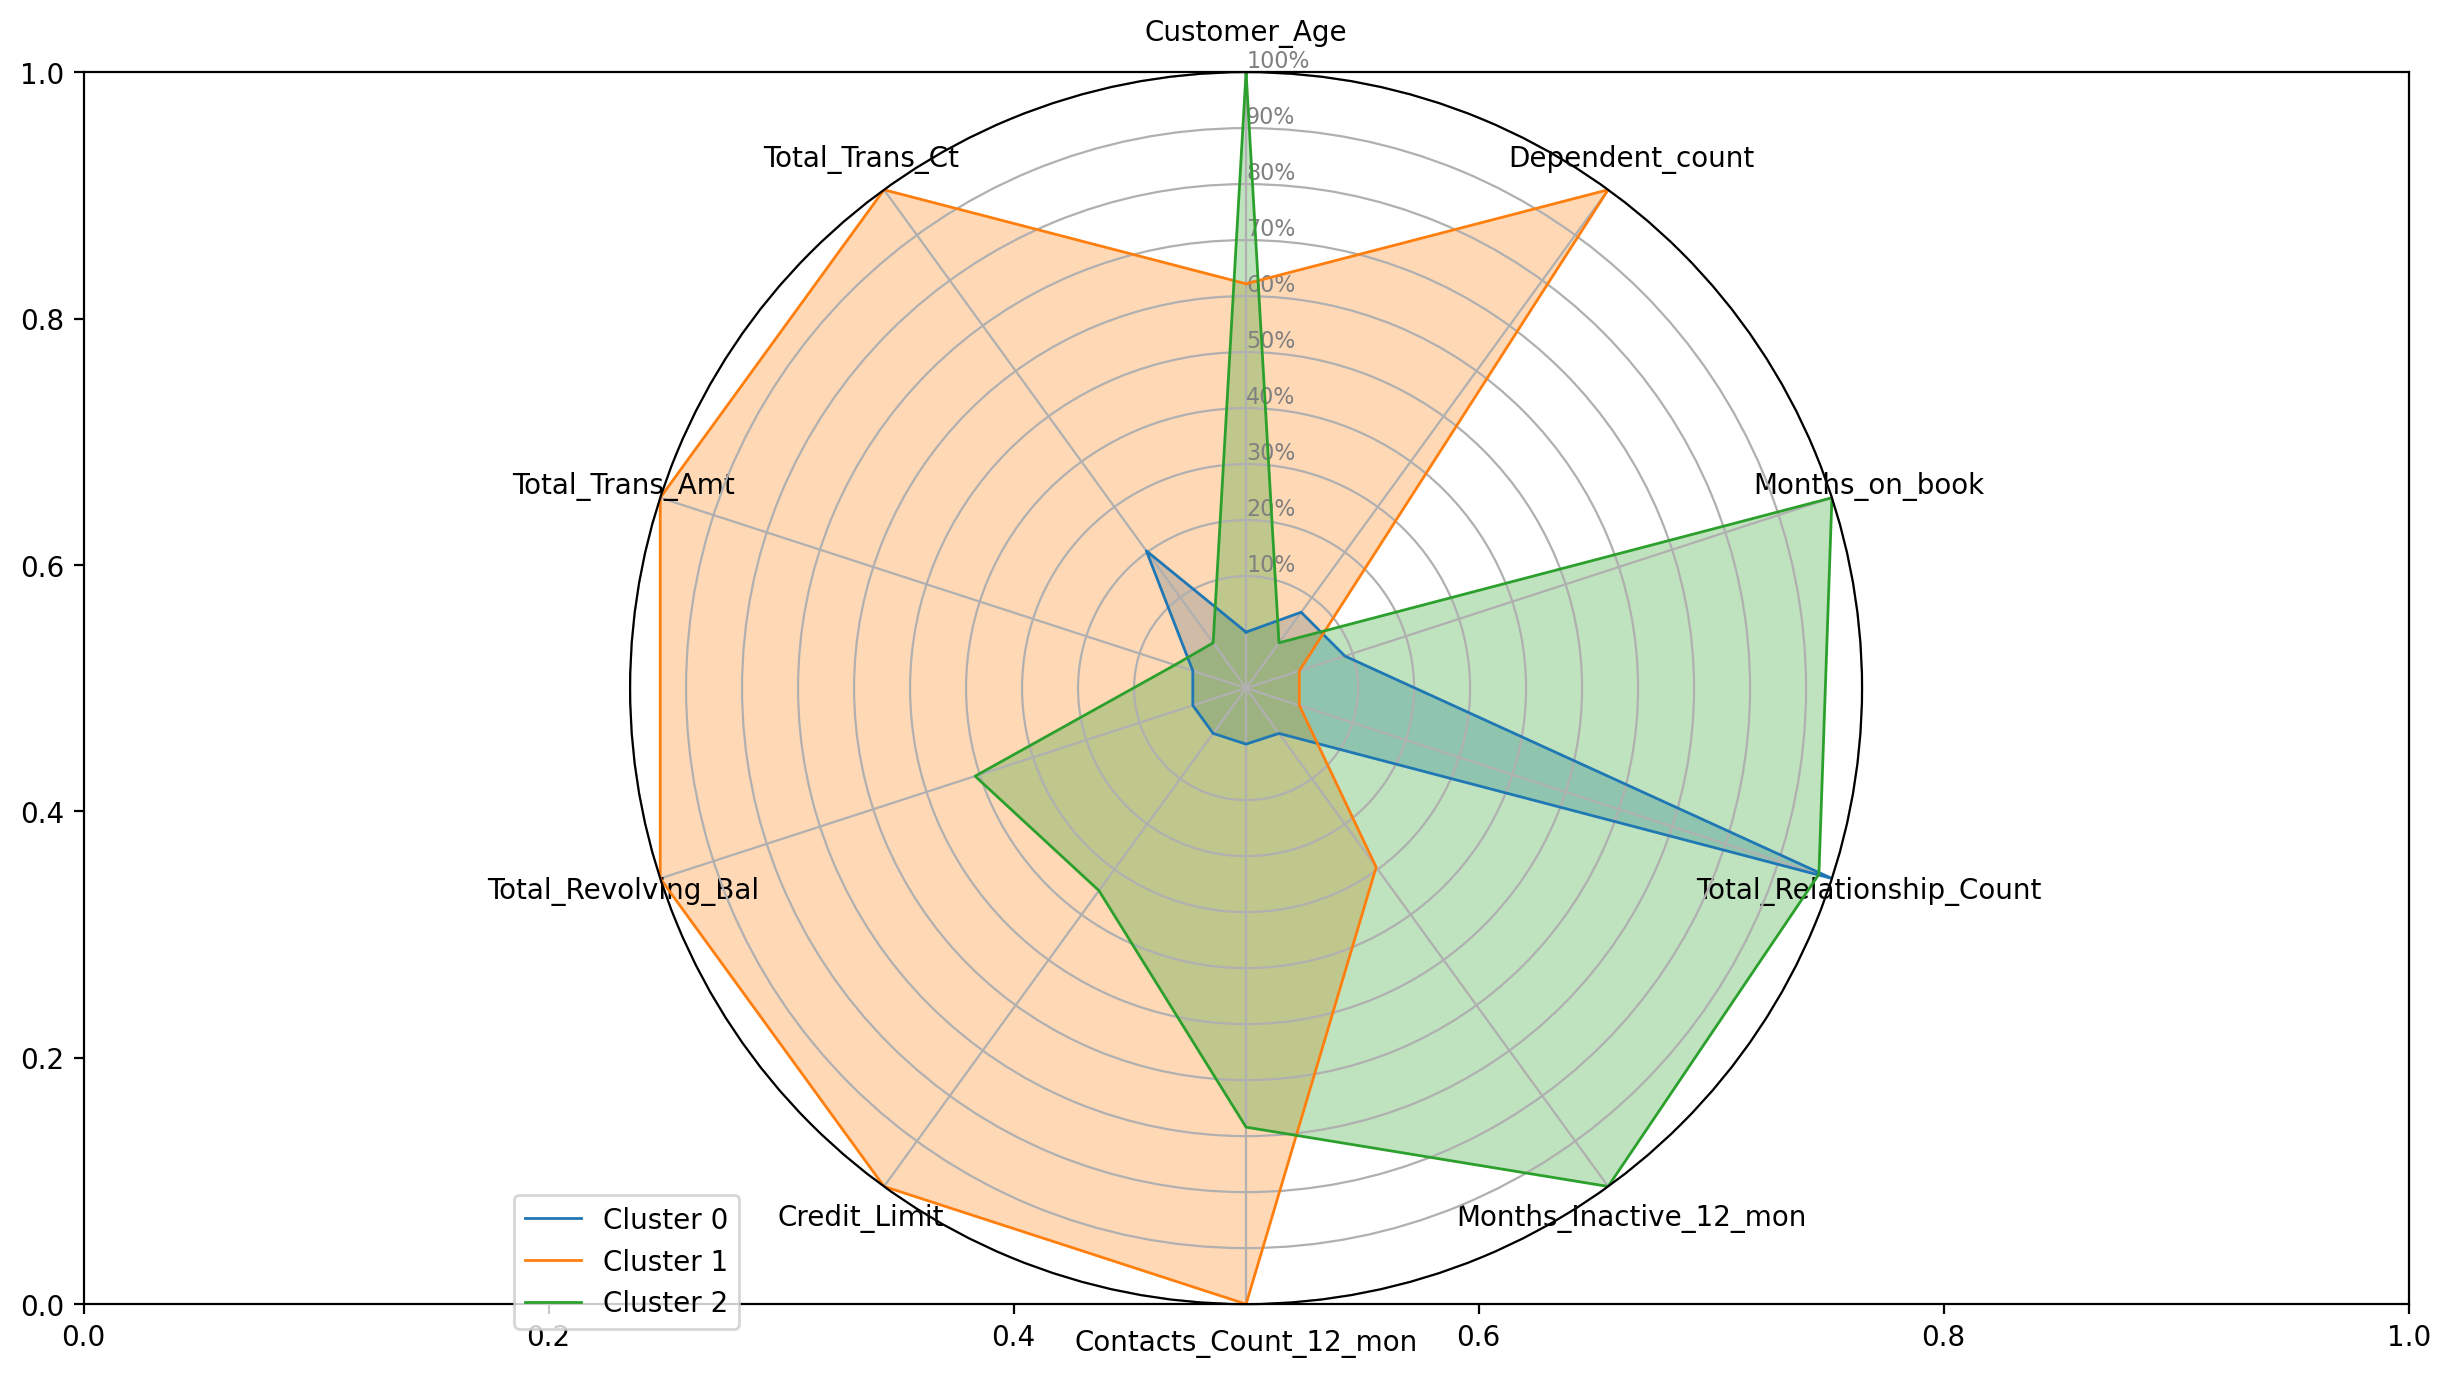

In [13]:
ns.radar_plot(centros, df_numerico.columns)
plt.show()

Datos shape
 (810, 10)
Componentes shape
 (810, 2)
Componentes
 [[-1015.1776289  -2515.05263757]
 [17536.4263045  -2708.0386159 ]
 [-4241.18388796   758.90565384]
 ...
 [ 4036.01022751 -1023.10851689]
 [-6682.52300773   391.45016519]
 [-3846.57812229 -1805.50736288]]


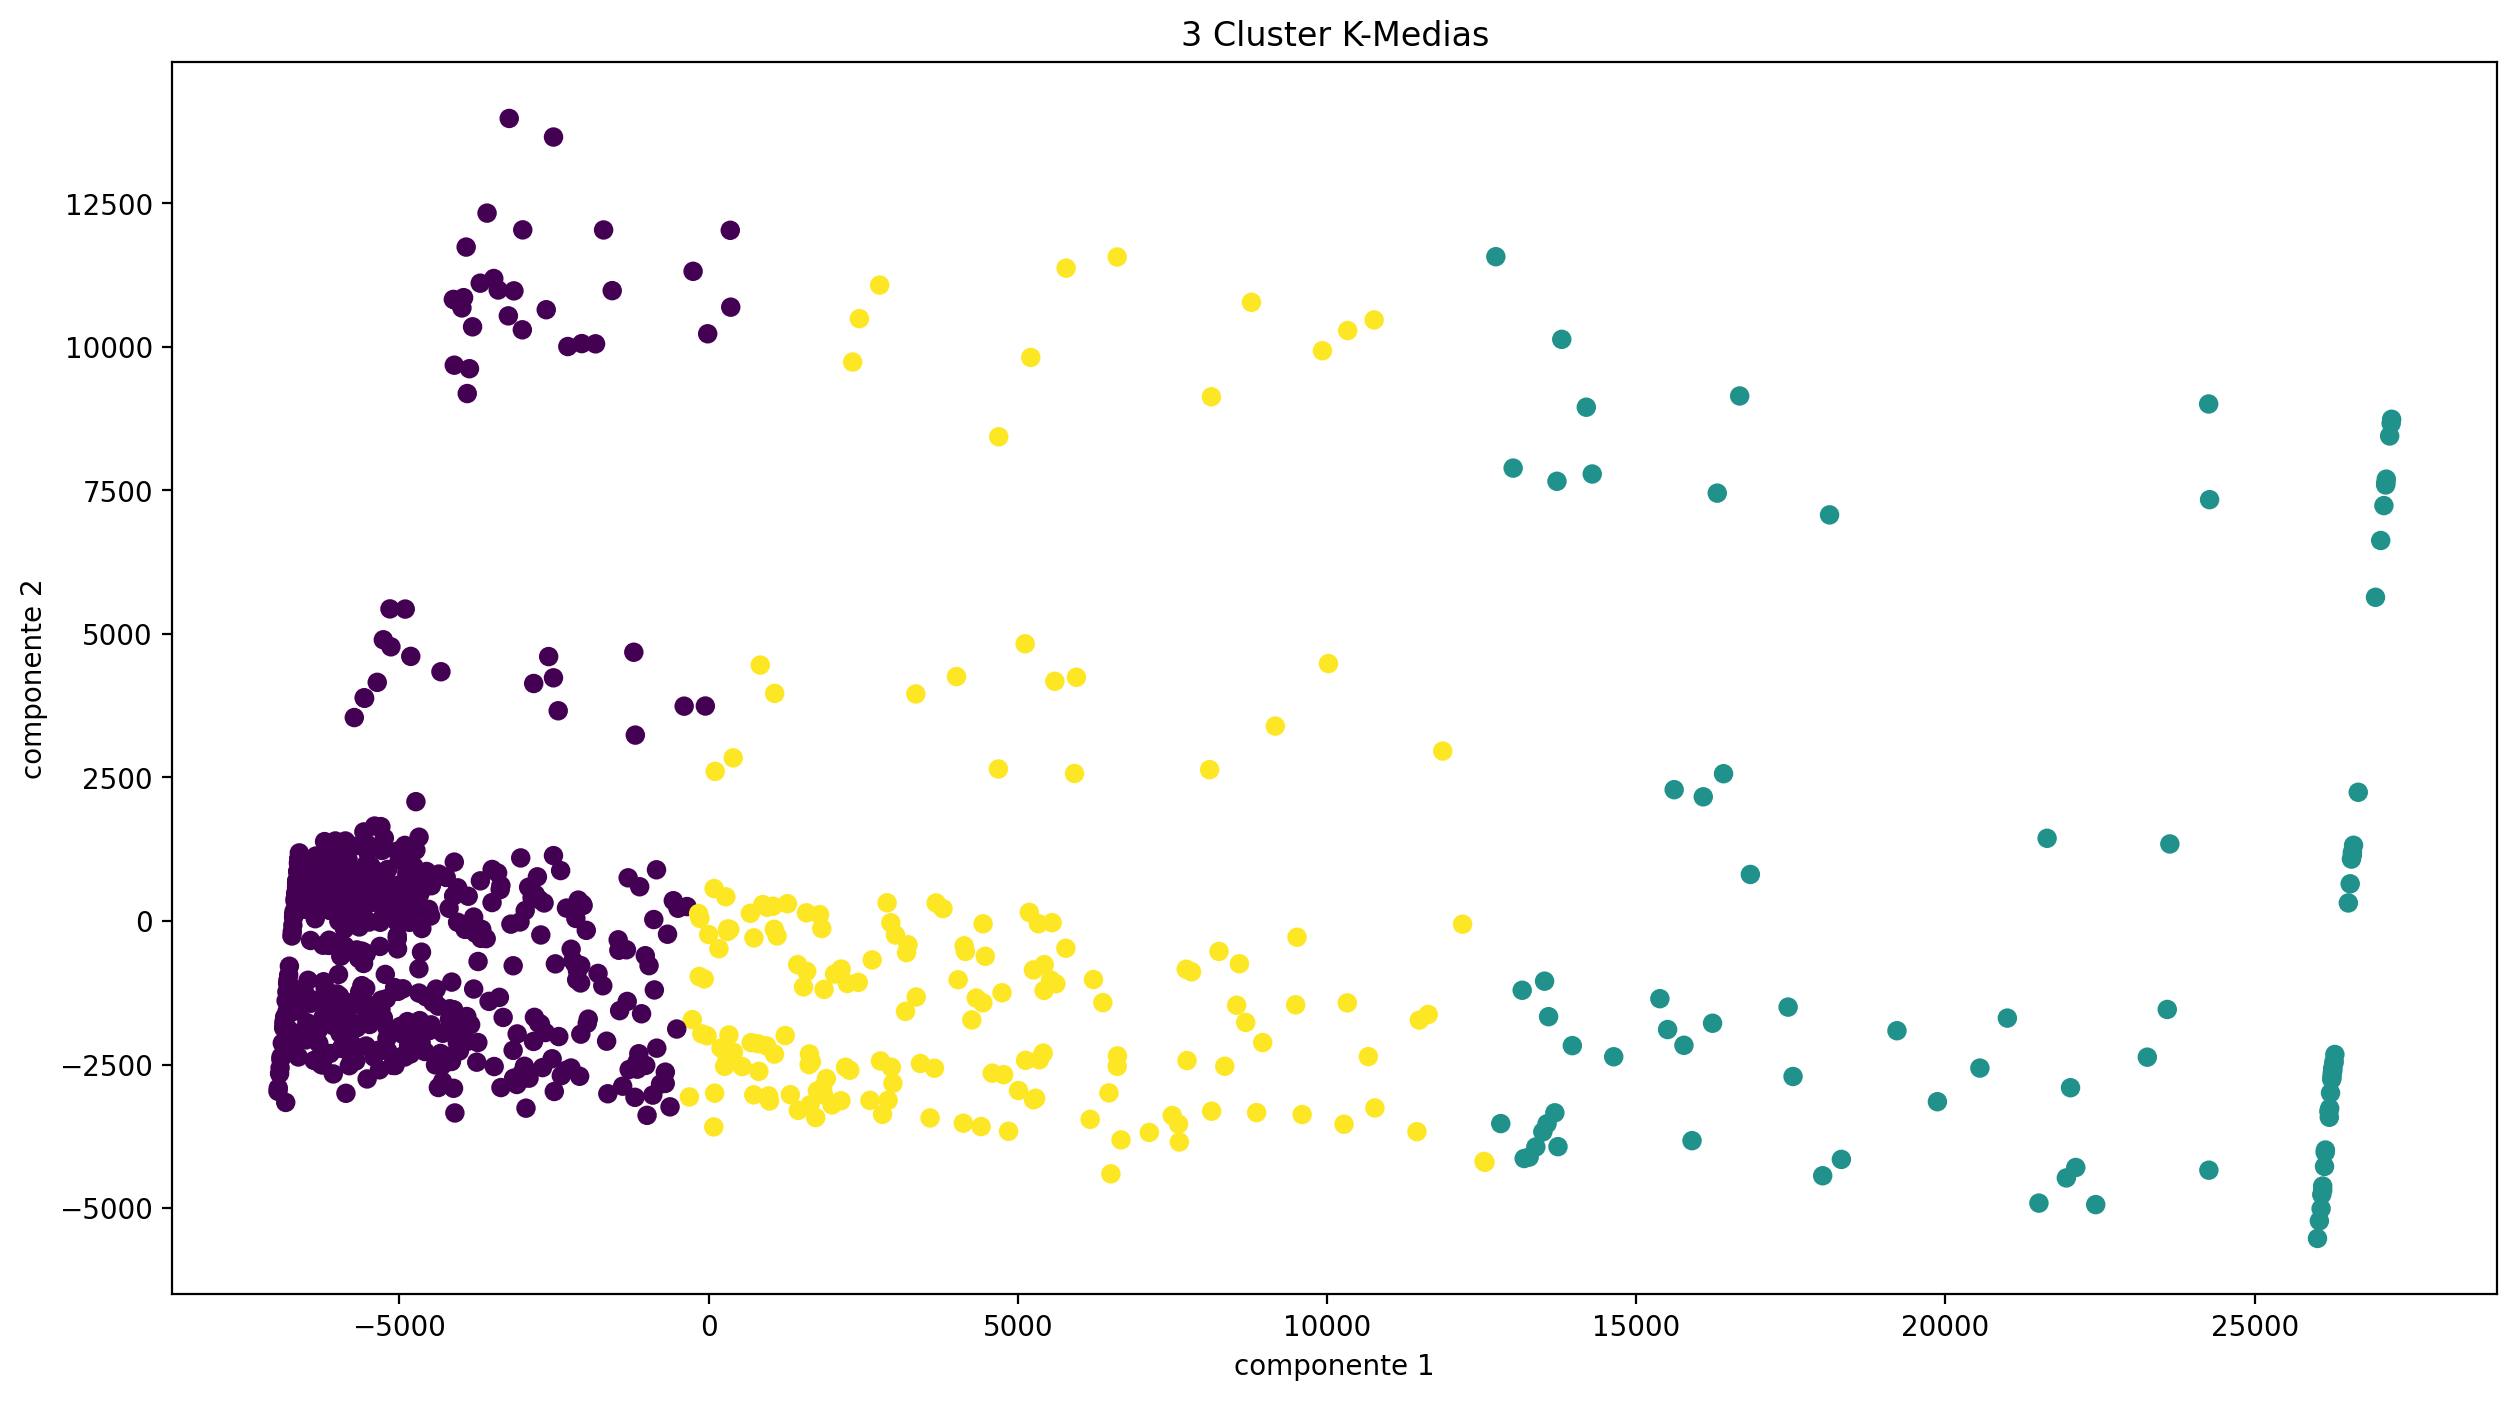

In [14]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_numerico)
print("Datos shape\n",df_numerico.shape)
print("Componentes shape\n",componentes.shape)
print("Componentes\n",componentes)

fig, ax = plt.subplots(1,1, figsize = (15,8), dpi = 200)
ax.scatter(componentes[:, 0], componentes[:, 1],c=kmedias.predict(df_numerico))
ax.set_xlabel('componente 1')
ax.set_ylabel('componente 2')
ax.set_title('3 Cluster K-Medias')
plt.show()

In [19]:
#opción c
# Ejecuta k-medoids con 3 clusters
kmedoids = KMedoids(n_clusters=3, max_iter=500, metric='cityblock')  # Declara la instancia de clase
kmedoids.fit(df_numerico)
print("Grupos\n",kmedoids.labels_)
centros = np.array(kmedoids.cluster_centers_)
print("Centros\n",centros)

Grupos
 [0 1 2 1 2 2 2 2 2 2 0 2 2 2 0 1 2 0 2 2 1 2 1 0 2 2 2 2 2 0 0 2 2 0 0 2 0
 2 0 2 0 1 2 1 2 2 1 2 0 2 2 2 2 0 2 2 0 2 0 2 2 2 2 0 2 2 1 2 2 2 0 2 1 0
 0 2 0 2 0 2 1 2 0 2 2 2 2 2 2 0 1 0 1 0 2 0 2 0 2 2 1 1 2 2 1 1 0 2 2 0 2
 0 2 0 2 2 0 0 0 1 2 0 2 0 2 1 0 2 2 0 2 1 2 1 2 2 2 2 0 1 0 2 1 2 2 1 2 1
 2 0 2 1 2 0 1 2 2 0 2 2 2 0 1 2 2 2 2 2 0 2 2 2 1 1 2 2 2 2 0 2 2 1 2 0 2
 2 2 2 0 2 2 0 2 2 2 0 1 0 2 2 0 0 2 1 2 2 0 2 2 0 2 2 2 2 0 0 2 2 1 2 2 2
 0 2 2 1 2 2 2 0 0 2 2 2 2 2 0 0 2 0 0 0 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 0 0
 2 2 0 2 2 2 1 2 0 2 0 0 2 2 2 2 1 0 1 2 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 1
 0 0 2 2 2 2 2 2 0 2 2 2 0 2 2 2 2 1 2 1 0 1 2 2 2 2 2 2 2 1 0 0 1 2 0 1 2
 2 2 0 2 2 0 2 2 2 2 0 2 2 0 0 2 0 2 1 2 2 0 1 2 0 1 1 2 2 0 2 0 2 2 0 2 0
 0 1 2 0 2 2 0 0 0 2 2 2 0 0 0 2 2 0 1 1 0 0 2 2 2 2 2 2 2 2 0 2 2 0 2 0 2
 2 2 2 0 0 1 2 2 1 2 1 2 2 1 0 0 0 1 0 0 0 2 2 2 0 0 0 1 2 2 2 0 2 2 2 2 2
 0 2 2 0 0 2 0 0 0 2 1 2 2 2 2 0 2 0 1 1 2 2 2 2 0 1 1 2 2 2 2 0 0 2 0 2 2
 0 2 1 0 2 2 2 0 

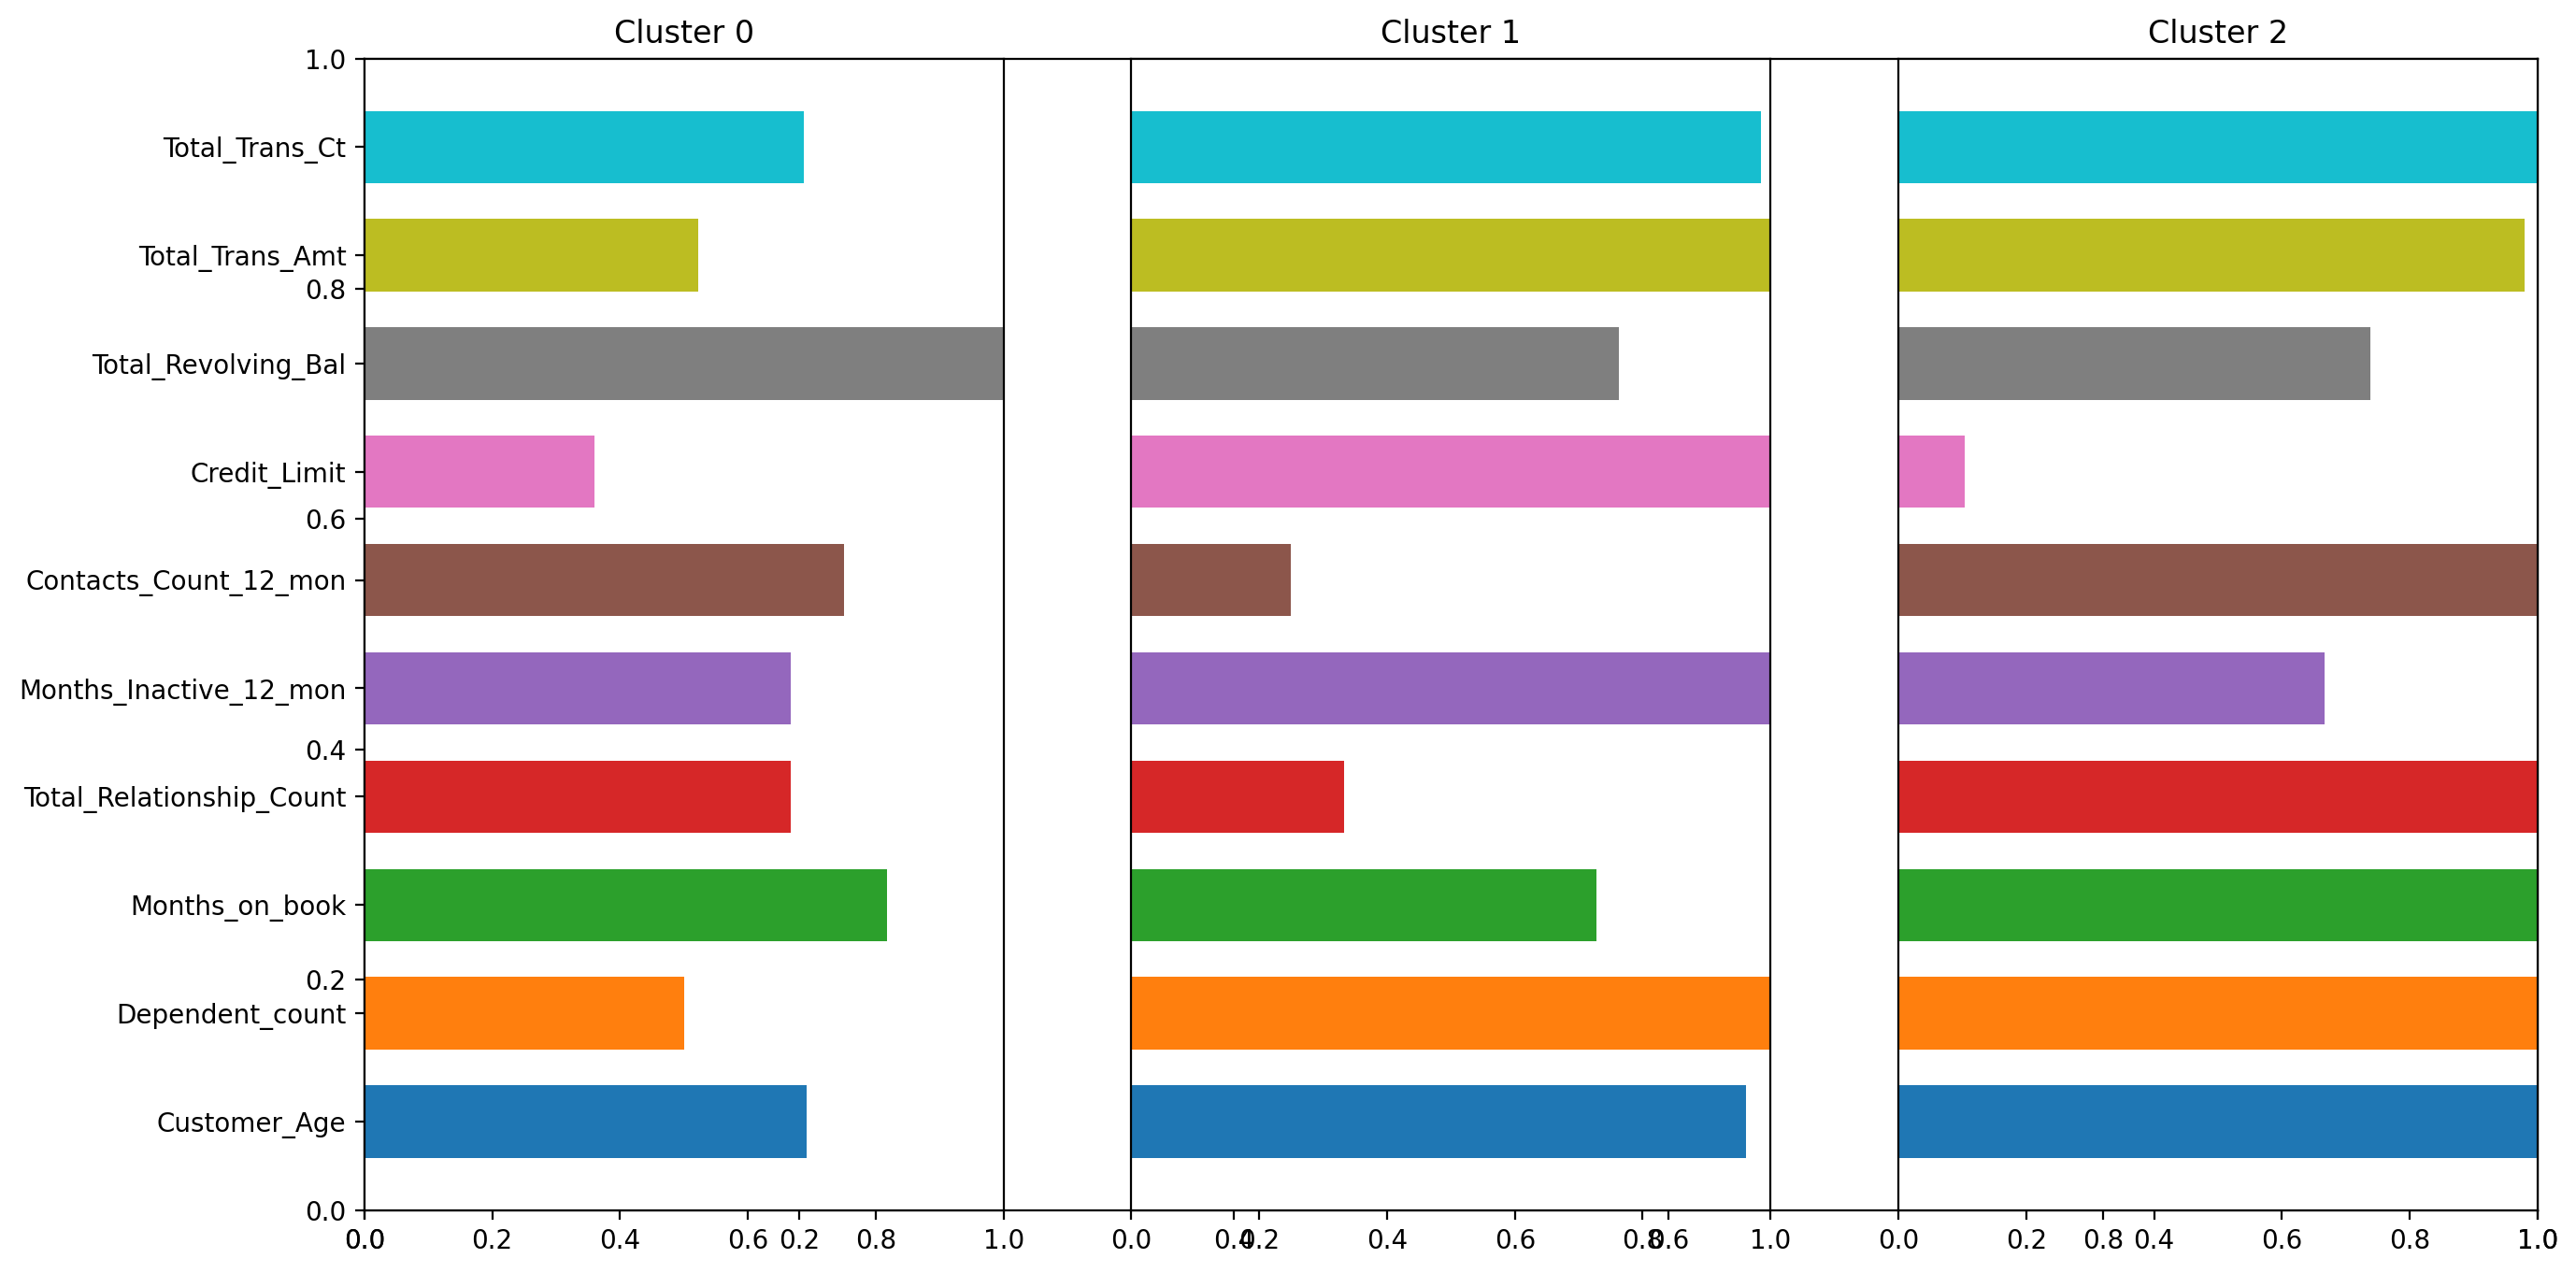

In [16]:
ns.bar_plot(centros, df_numerico.columns,scale=True)
plt.show()

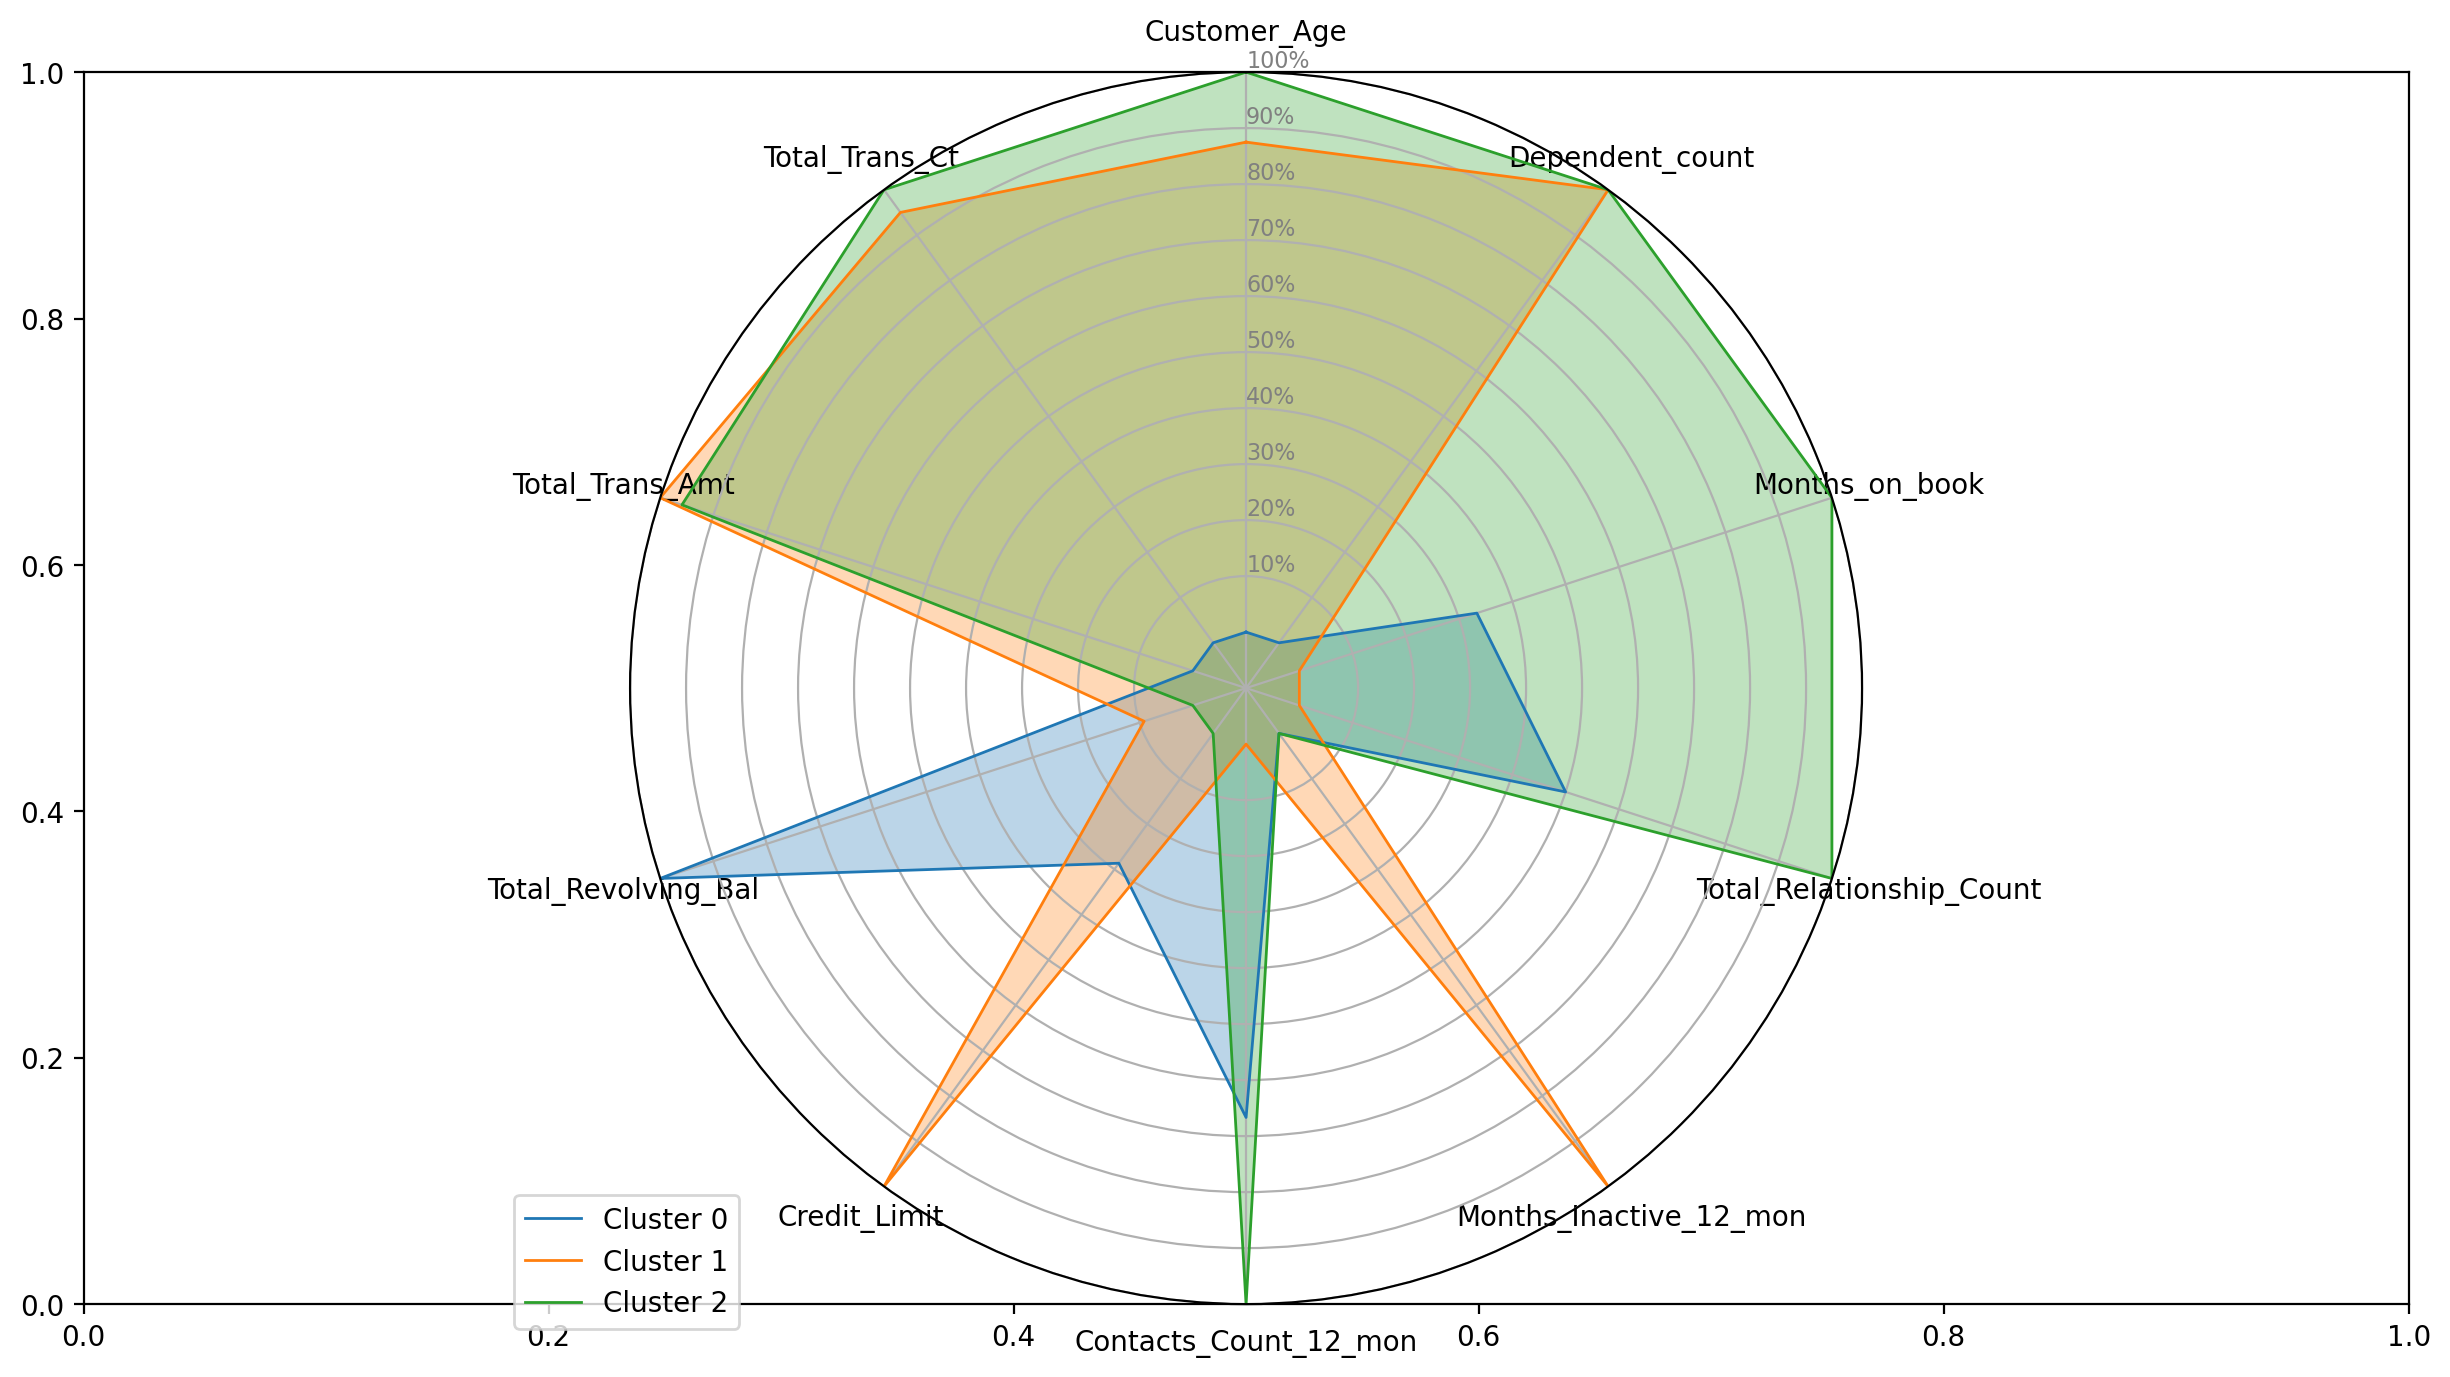

In [17]:
ns.radar_plot(centros, df_numerico.columns)
plt.show()

Datos shape
 (810, 10)
Componentes shape
 (810, 2)
Componentes
 [[-1015.1776289  -2515.05263757]
 [17536.4263045  -2708.0386159 ]
 [-4241.18388796   758.90565384]
 ...
 [ 4036.01022751 -1023.10851689]
 [-6682.52300773   391.45016519]
 [-3846.57812229 -1805.50736288]]


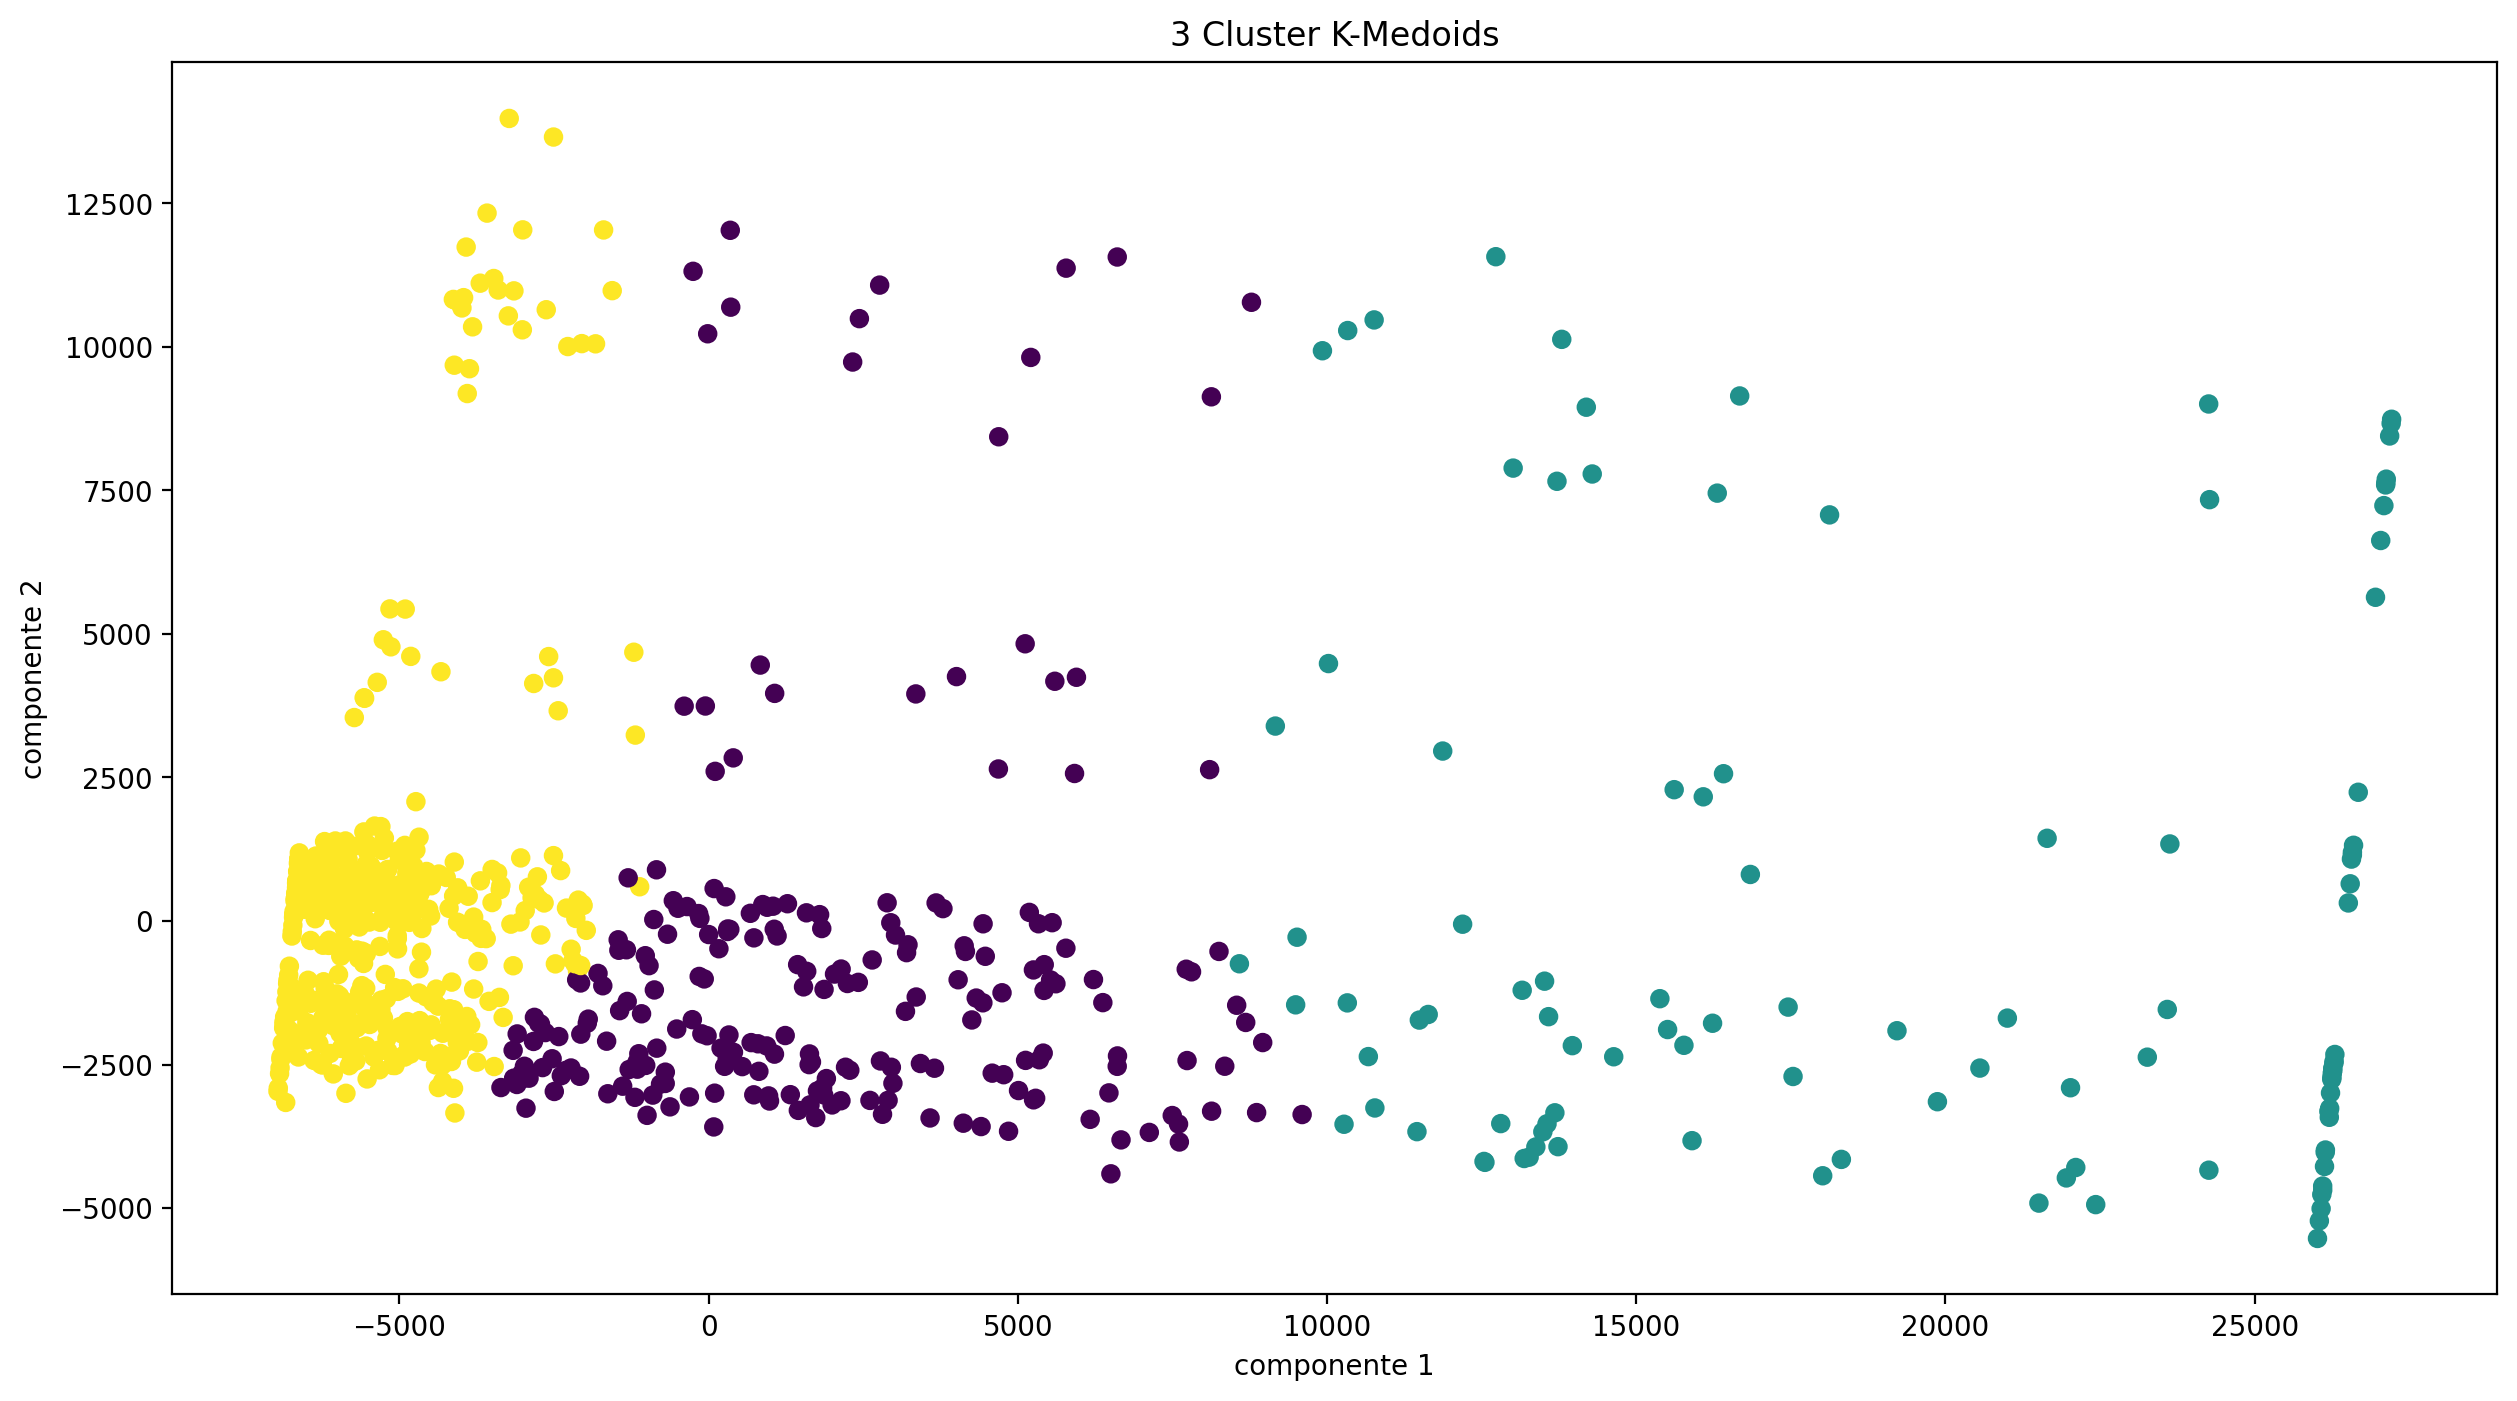

In [18]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_numerico)
print("Datos shape\n",df_numerico.shape)
print("Componentes shape\n",componentes.shape)
print("Componentes\n",componentes)

fig, ax = plt.subplots(1,1, figsize = (15,8), dpi = 200)
ax.scatter(componentes[:, 0], componentes[:, 1],c=kmedoids.labels_)
ax.set_xlabel('componente 1')
ax.set_ylabel('componente 2')
ax.set_title('3 Cluster K-Medoids')
plt.show()